# Function Declarations

Run once

In [196]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

In [197]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

## Plot Confusion Matrix

In [198]:
def plot_confusion_matrix(cm_data, forwhat='', sensible_attribute='', mapping={}):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Weights Functions



### $w_i = 1 + \lambda * Penalty(g_i) $

In [199]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [200]:
def compute_weights_notsized(lambda_=5.0, m='FPN', penalties_onval=None, X_train=None, sensible_attribute=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [201]:
# df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [202]:
def compute_weights_sized(lambda_=1.0, m='PPE', penalties_onval=None, X_train=None, sensible_attribute=None):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

---

## Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [203]:
def compute_penalties_after_reweighting(weights, fairness_metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}

    for attribute in attributes:        
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Convert string combinations to numeric codes for XGBoost
        X_train_numeric = X_train[attribute].copy()
        X_train_numeric[attribute] = X_train_numeric[attribute].astype('category').cat.codes
        
        X_test_numeric = X_test[attribute].copy()
        X_test_numeric[attribute] = X_test_numeric[attribute].astype('category').cat.codes
        
        # Train model with weights on combined attribute
        model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_reweighed.fit(X_train_numeric, y_train[attribute], sample_weight=weights)
        
        # Predict on test set
        y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

        cm = confusion_matrix(y_test[attribute], y_pred_test_reweighed_combined, labels=target_variable_labels)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

In [204]:
def performance_after_reweighting(weights, sensible_attribute, X_train, y_train, X_test, y_test): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


### Plots

In [205]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}, λ: {lambd}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

In [206]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, lambd):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison, λ: {lambd}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

In [207]:
def plot_penalty_comparison_lambdas(fairness_metric, lambdas, penalties_ontest, penalties_after_by_lambda, sensible_attribute, mapping):
    """
    Plot penalty comparison across different lambda values for a single fairness metric.
    
    Args:
        fairness_metric: Single fairness metric to plot (e.g., 'FPN')
        lambdas: List of lambda values
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after_by_lambda: Dictionary mapping lambda to penalties after reweighting
                                  {lambda: {metric: {subgroup: penalty}}}
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups
    subgroups = list(penalties_ontest[fairness_metric].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Determine grid size based on number of lambdas
    n_lambdas = len(lambdas)
    if n_lambdas <= 3:
        nrows, ncols = 1, n_lambdas
    elif n_lambdas <= 6:
        nrows, ncols = 2, 3
    elif n_lambdas <= 9:
        nrows, ncols = 3, 3
    else:
        nrows, ncols = 3, 4
    
    # Set up the plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
    if n_lambdas == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_lambdas > 1 else [axes]
    
    # Get penalties before reweighting (same for all lambdas)
    penalties_before = [penalties_ontest[fairness_metric].get(group, 0) for group in subgroups]
    
    # Create a bar plot for each lambda
    for idx, lambd in enumerate(lambdas):
        ax = axes[idx]
        
        # Extract penalties after for this lambda
        penalties_after = [penalties_after_by_lambda[lambd][fairness_metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'λ = {lambd}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically
        decoded_labels = []
        for group in subgroups:
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    # Remove extra subplots if any
    for idx in range(n_lambdas, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison Across Lambda Values\nMetric: {fairness_metric}, Subgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.09)
    plt.show()

# Experiment Runs

# ADULT CENSUS

## Parameters

Made so they can be easily changed

In [208]:
# Flags
ALL_FM_L_NOTSIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using notsized weights
SIZED = 0 # Set to 1 to add plots using sized weights
ALL_FM_L_SIZED = 0  # Set to 1 to plot all fairness metrics specified in 'fair_metrics' for all lambdas in 'lambdas' when using sized weights

In [209]:
datasets = {0: 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv', 
            1: '/COMPAS/compas-preprocessed-binary.csv', 
            2: '/GermanCredit/german-preprocessed-binary.csv'}

dataset_path = datasets[0]

In [210]:
sensible_attribute = 'sex-race'

In [ ]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

models = {
    'xgb': xgb.XGBClassifier(random_state=1234, eval_metric='logloss'),
    'lgbm': lgb.LGBMClassifier(random_state=1234, verbose=-1),
    'cb': cb.CatBoostClassifier(random_state=1234, verbose=False)
  }

selected_model = models['lgbm']

In [ ]:
# ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
fair_metrics = ['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']

In [ ]:
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

In [ ]:
fixed_lambda = 5.0

In [ ]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


In [ ]:
import pandas as pd

df=pd.read_csv(dataset_path)

if dataset_path == datasets[0]:  # Adult Census
    protected_attributes =['age', 'sex', 'race', 'edu']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'edu':{
            0: 'low-edu',
            1: 'high-edu'
        },
        'sex':{
            0: 'female',
            1: 'male'
        },
        'race':{
            0: 'Amer-Black-Other',
            1: 'Asian-White'
        }
    }
    feature_cols= df.columns
    target_variable = 'income'
elif dataset_path == datasets[1]:  # COMPAS
    protected_attributes =['age', 'sex', 'race']
    mapping= {
        'age':{
            0: 'age<35',
            1: 'age>35',
        },
        'sex':{
            0: 'fem',
            1: 'mal'
        },
        'race':{
            0: 'African',
            1: 'AsiaWhiHispNatOth'
        }
    }
    feature_cols= df.columns
    target_variable = 'is_violent_recid'
elif dataset_path == datasets[2]:  # German Credit
    protected_attributes =['age', 'sex']
    mapping= {
        'age':{
            0: 'young',
            1: 'adult'
        },
        'sex':{
            0: 'female',
            1: 'male'
        }
    }
    feature_cols= df.columns
    target_variable = 'risk'

target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [ ]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}
performance_metrics_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}
performance_metrics_test = {}

for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set | Model 1A
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], \
                              target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set | Model 1B
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
    compute_model_predictions_general(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], \
                                      target_variable_labels, attribute, selected_model)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7567287784679089, Recall: 0.6117154811715482, Accuracy: 0.8568796068796068, F1: 0.6765386395187413
{np.int64(0): array([[1446,   22],
       [  83,   98]]), np.int64(1): array([[2008,  213],
       [ 381,  633]])}
sex
Precision: 0.774384236453202, Recall: 0.6517412935323383, Accuracy: 0.8671443193449335, F1: 0.7077892841062584
{np.int64(0): array([[1406,   24],
       [  87,   93]]), np.int64(1): array([[2044,  205],
       [ 333,  693]])}
race
Precision: 0.7567287784679089, Recall: 0.6117154811715482, Accuracy: 0.8568796068796068, F1: 0.6765386395187413
{np.int64(1): array([[2983,  228],
       [ 426,  703]]), np.int64(0): array([[471,   7],
       [ 38,  28]])}
race
Precision: 0.774384236453202, Recall: 0.6517412935323383, Accuracy: 0.8671443193449335, F1: 0.7077892841062584
{np.int64(1): array([[2964,  221],
       [ 373,  757]]), np.int64(0): array([[486,   8],
       [ 47,  29]])}
sex-race
Precision: 0.7590861889927311, Recall: 0.6117154811715482, Accuracy: 0.8574

In [ ]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

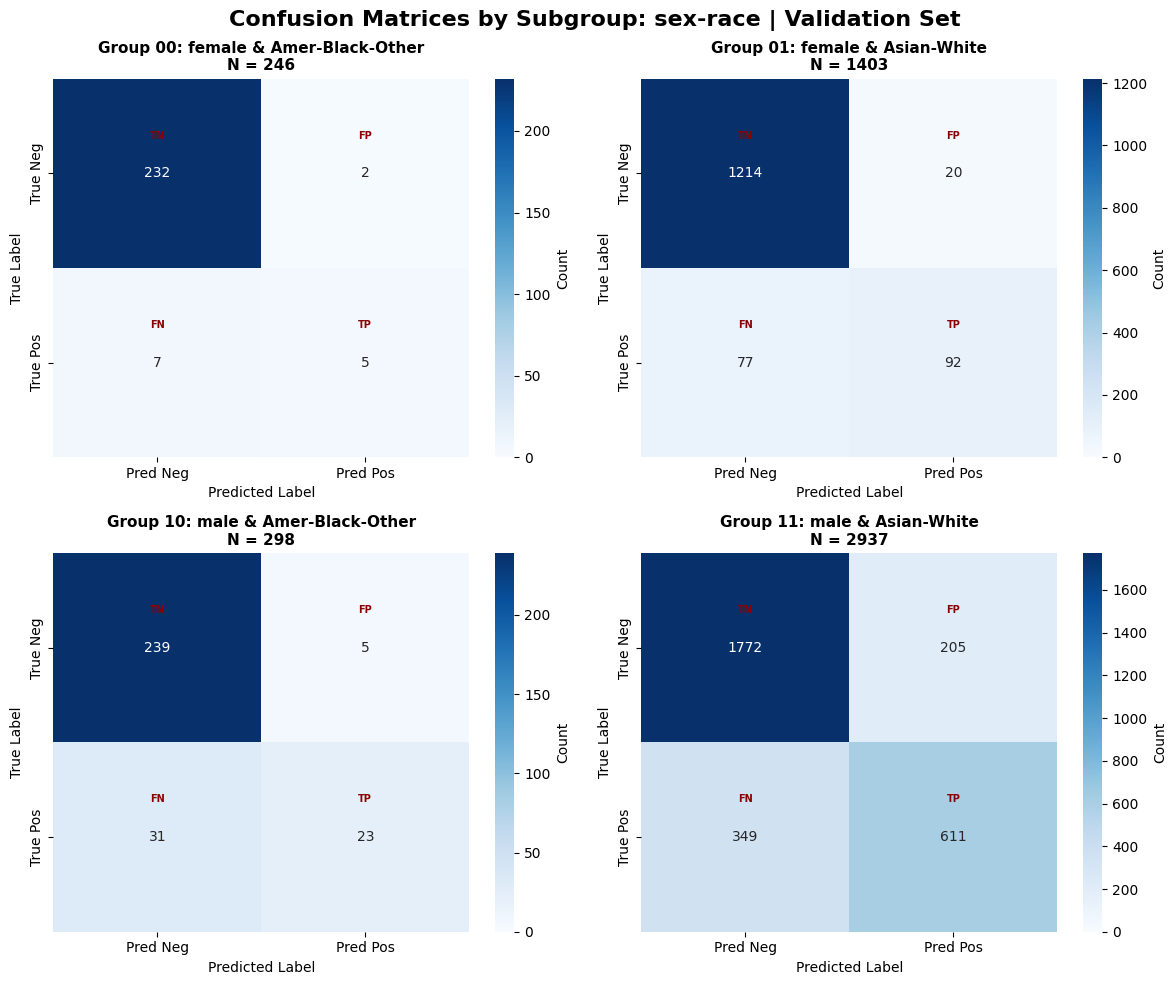

In [ ]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set', sensible_attribute, mapping)

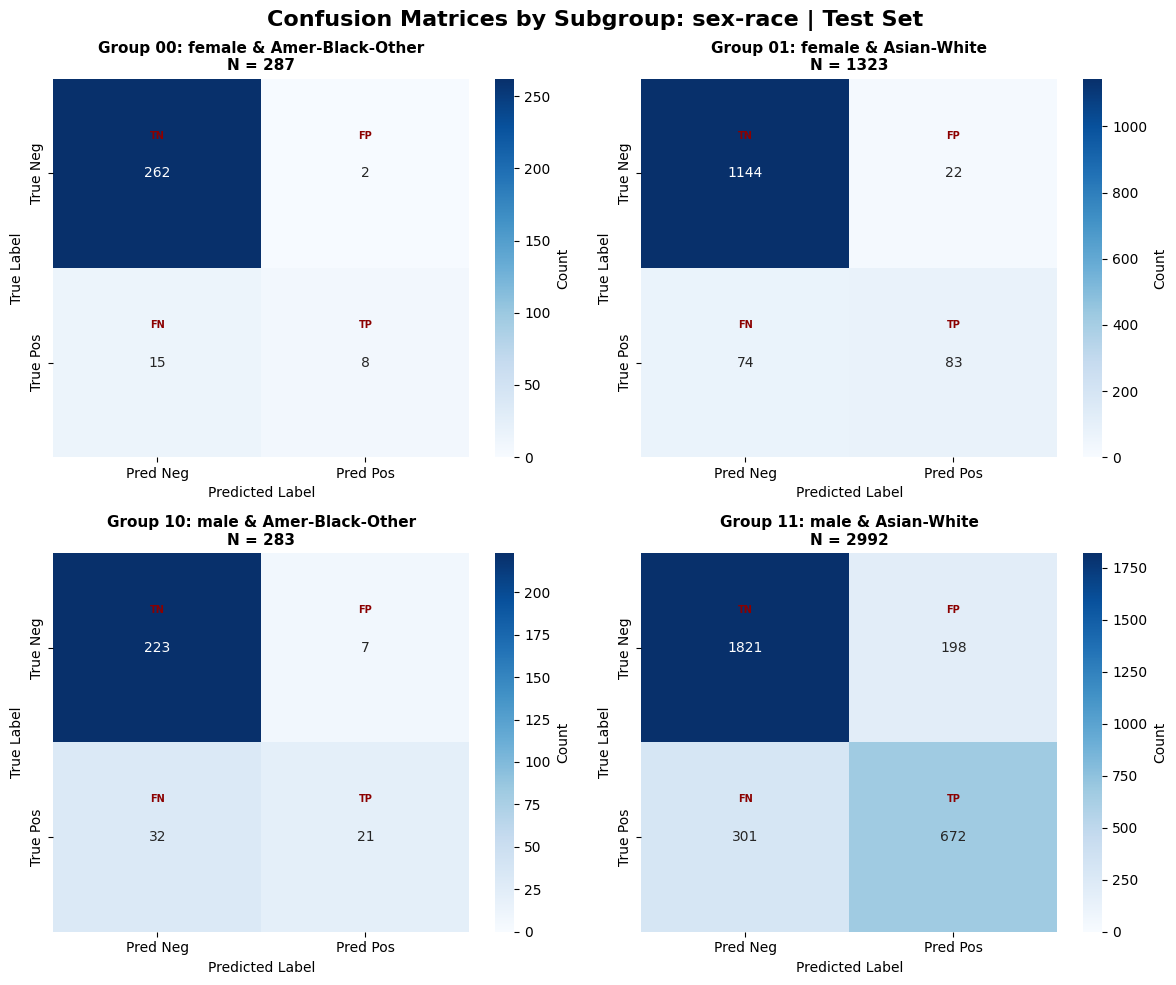

In [ ]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set', sensible_attribute, mapping)

In [ ]:
weights_notsized = compute_weights_notsized(fixed_lambda, 'FPN', penalties_onval, X_train, sensible_attribute)
performance_metrics_after = performance_after_reweighting(weights_notsized, sensible_attribute, X_train, y_train, X_test, y_test)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
Precision: 0.7750247770069376, Recall: 0.648424543946932, Accuracy: 0.8667349027635619, F1: 0.7060948081264108


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

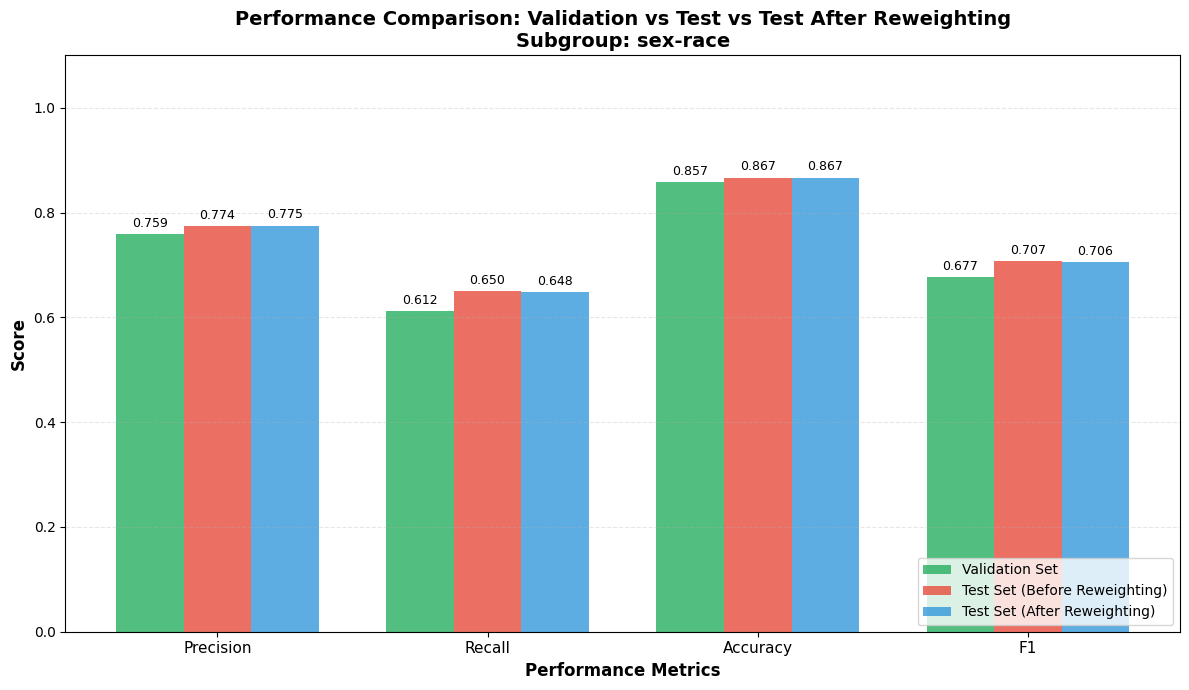


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.7591          0.7739          0.7750          +0.0011
Recall          0.6117          0.6501          0.6484          -0.0017
Accuracy        0.8575          0.8667          0.8667          +0.0000
F1              0.6775          0.7066          0.7061          -0.0005


In [ ]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

# Penalty After Reweighting Plots

### Utils

In [ ]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1409,   21],
       [  92,   88]]), np.int64(1): array([[2047,  202],
       [ 332,  694]])}
{np.int64(1): array([[2969,  216],
       [ 379,  751]]), np.int64(0): array([[487,   7],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  79,   78]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[225,   5],
       [ 31,  22]])}
Training samples: 22792, Unique weights per group: {'00': 3.1151071151071146, '01': 2.725664260105102, '10': 1.967574573121791, '11': 0.01}
{np.int64(0): array([[1407,   23],
       [  90,   90]]), np.int64(1): array([[2039,  210],
       [ 379,  647]])}
{np.int64(1): array([[2968,  217],
       [ 436,  694]]), np.int64(0): array([[478,  16],
       [ 33,  43]])}
{'01': array([[1145,   21],
       [  76,   81]]), '00': array([[262,   2

## Penalty before and after reweighting

In [ ]:
def create_penalty_comparison_table(penalties_before, penalties_after, sensible_attribute, mapping, metrics_to_show=None):
    """
    Create a comprehensive table comparing penalties before and after reweighting.
    
    Args:
        penalties_before: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_after: Dictionary of penalties after reweighting {metric: {subgroup: penalty}}
        sensible_attribute: Combined attribute string (e.g., 'sex-race')
        mapping: Dictionary mapping attribute codes to labels
        metrics_to_show: List of metrics to display (None = all metrics)
    
    Returns:
        DataFrame with comparison statistics
    """
    import pandas as pd
    
    # If no specific metrics requested, show all
    if metrics_to_show is None:
        metrics_to_show = list(penalties_before.keys())
    
    # Parse individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Collect data for table
    table_data = []
    
    for metric in metrics_to_show:
        if metric not in penalties_before or metric not in penalties_after:
            continue
            
        for subgroup in penalties_before[metric].keys():
            before = penalties_before[metric][subgroup]
            after = penalties_after[metric][subgroup]
            diff = after - before
            
            # Calculate percentage reduction
            if before != 0:
                pct_reduction = ((before - after) / abs(before)) * 100
            else:
                pct_reduction = 0
            
            # Decode subgroup label
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(subgroup[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            decoded_label = '-'.join(decoded_parts)
            
            table_data.append({
                'Metric': metric,
                'Subgroup': decoded_label,
                'Before': f"{before:.2f}",
                'After': f"{after:.2f}",
                'Difference': f"{diff:+.2f}",
                'Reduction (%)': f"{pct_reduction:.1f}%"
            })
    
    df = pd.DataFrame(table_data)
    return df

In [ ]:
# Create comprehensive comparison table for all metrics
df_comparison = create_penalty_comparison_table(
    penalties_ontest, 
    penalties_ontest_after_reweighting, 
    sensible_attribute, 
    mapping
)

print("\n" + "="*100)
print(f"PENALTY COMPARISON: BEFORE vs AFTER REWEIGHTING (λ={fixed_lambda})")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Also create a focused table for key metrics
print("\n\nKEY METRICS SUMMARY")
print("="*100)
key_metrics = ['FPN', 'PPE', 'EOP']
df_key = create_penalty_comparison_table(
    penalties_ontest, 
    penalties_ontest_after_reweighting, 
    sensible_attribute, 
    mapping,
    metrics_to_show=key_metrics
)
print(df_key.to_string(index=False))
print("="*100)


PENALTY COMPARISON: BEFORE vs AFTER REWEIGHTING (λ=5.0)
Metric                Subgroup Before  After Difference Reduction (%)
   FPN female-Amer-Black-Other  32.35 -13.03     -45.38        140.3%
   FPN      female-Asian-White  16.21  17.82      +1.61        -10.0%
   FPN   male-Amer-Black-Other  14.75  30.05     +15.31       -103.8%
   FPN        male-Asian-White  -5.39  -7.64      -2.25         41.7%
   PPE female-Amer-Black-Other  54.04  64.75     +10.71        -19.8%
   PPE      female-Asian-White  30.19  30.79      +0.60         -2.0%
   PPE   male-Amer-Black-Other -10.66 -17.52      -6.86         64.3%
   PPE        male-Asian-White -24.46 -21.97      +2.49        -10.2%
   GFA female-Amer-Black-Other  49.19  49.32      +0.13         -0.3%
   GFA      female-Asian-White  27.89  24.47      -3.41         12.2%
   GFA   male-Amer-Black-Other   5.75 -51.47     -57.22        995.5%
   GFA        male-Asian-White -17.17 -17.15      +0.02         -0.1%
   PPA female-Amer-Black-Other  -

In [ ]:
# Summary statistics per metric (averaged across subgroups)
print("\n\nSUMMARY: AVERAGE PENALTY REDUCTION BY METRIC")
print("="*80)

summary_data = []
for metric in fair_metrics:
    if metric in penalties_ontest and metric in penalties_ontest_after_reweighting:
        before_values = list(penalties_ontest[metric].values())
        after_values = list(penalties_ontest_after_reweighting[metric].values())
        
        avg_before = np.mean(before_values)
        avg_after = np.mean(after_values)
        avg_reduction = avg_before - avg_after
        pct_reduction = (avg_reduction / abs(avg_before)) * 100 if avg_before != 0 else 0
        
        summary_data.append({
            'Metric': metric,
            'Avg Before': f"{avg_before:.2f}",
            'Avg After': f"{avg_after:.2f}",
            'Avg Reduction': f"{avg_reduction:.2f}",
            'Reduction (%)': f"{pct_reduction:.1f}%"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("="*80)



SUMMARY: AVERAGE PENALTY REDUCTION BY METRIC
Metric Avg Before Avg After Avg Reduction Reduction (%)
   FPN      14.48      6.80          7.68         53.0%
   PPE      12.28     14.01         -1.74        -14.1%
   GFA      16.41      1.29         15.12         92.1%
   PPA       0.37     -0.48          0.85        230.8%
   OAE      -0.91     -1.24          0.33         36.9%
   FPR      -1.30     -8.76          7.45        572.8%
   FPA       3.38     15.24        -11.86       -351.4%
   EOP     -19.17    -18.72         -0.45         -2.3%
   FNP       1.00     14.06        -13.06      -1302.2%
   FPP      13.61     17.81         -4.19        -30.8%


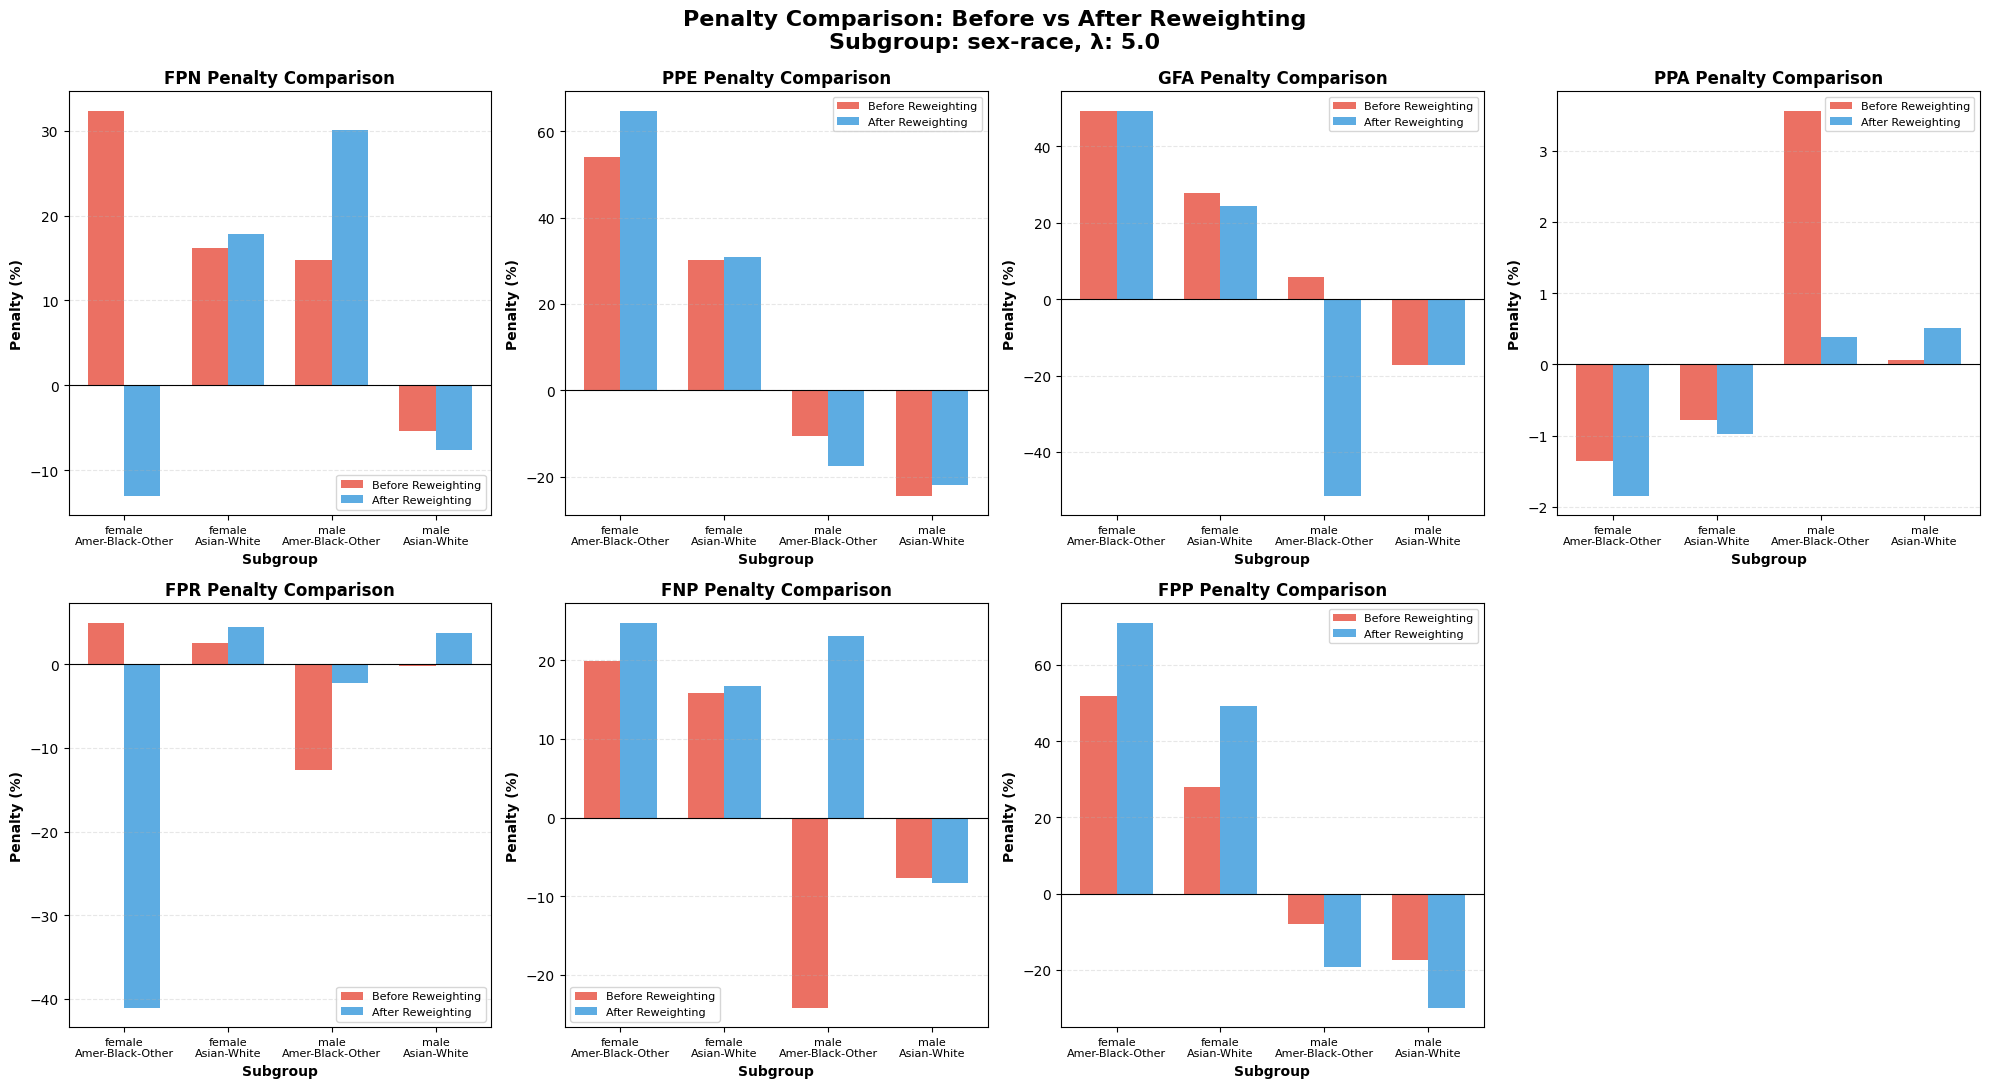

In [ ]:
# Use as many fairness metrics as needed
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1409,   21],
       [  92,   88]]), np.int64(1): array([[2047,  202],
       [ 332,  694]])}
{np.int64(1): array([[2969,  216],
       [ 379,  751]]), np.int64(0): array([[487,   7],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  79,   78]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[225,   5],
       [ 31,  22]])}


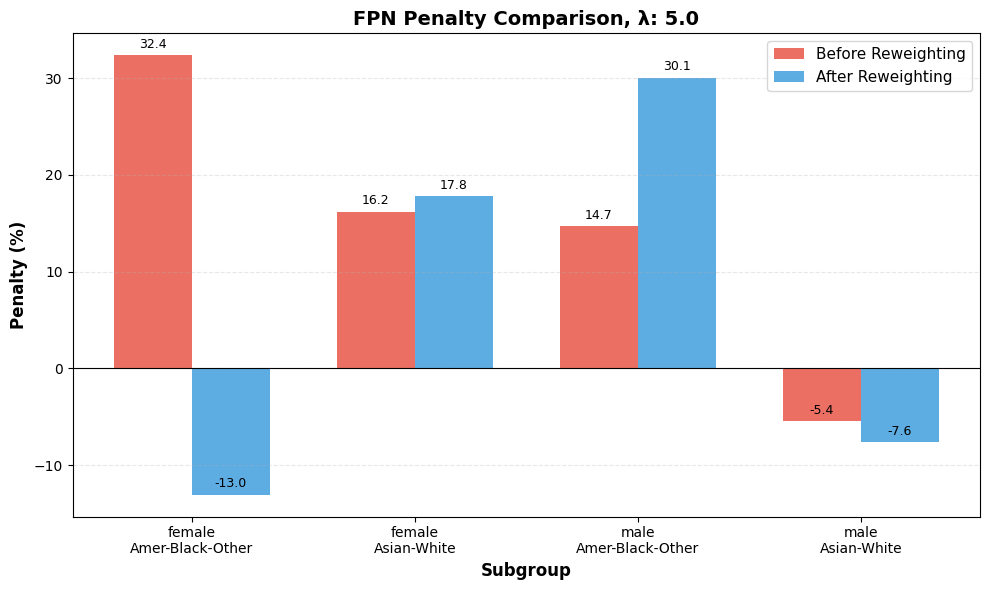


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → -13.03 (Δ = -45.38)
  female-Asian-White: 16.21 → 17.82 (Δ = +1.61)
  male-Amer-Black-Other: 14.75 → 30.05 (Δ = +15.31)
  male-Asian-White: -5.39 → -7.64 (Δ = -2.25)
------------------------------------------------------------


In [ ]:
metrics = ['FPN']
penalties_ontest_after_reweighting = {}
for metric in metrics:
    weights_notsized = compute_weights_notsized(fixed_lambda, metric, penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

plot_penalty_comparison_all_individual(metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping, fixed_lambda)

Training samples: 22792, Unique weights per group: {'00': 0.8777056277056277, '01': 1.1061263749815025, '10': 1.1799547283702214, '11': 0.9766622488111263}
{np.int64(0): array([[1407,   23],
       [  89,   91]]), np.int64(1): array([[2048,  201],
       [ 337,  689]])}
{np.int64(1): array([[2967,  218],
       [ 379,  751]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1135,   31],
       [  70,   87]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1817,  202],
       [ 295,  678]]), '10': array([[225,   5],
       [ 33,  20]])}


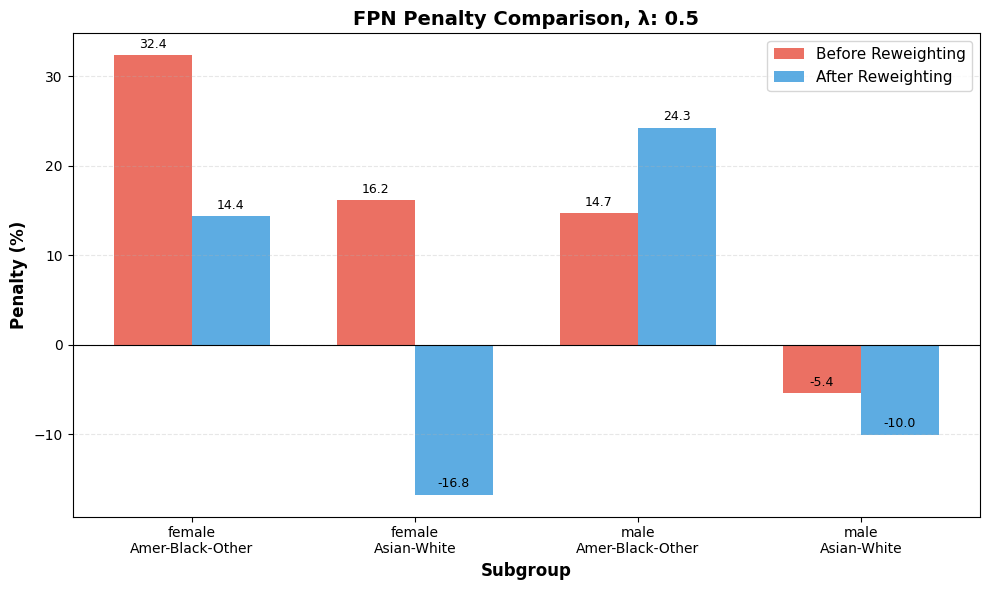


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → 14.36 (Δ = -18.00)
  female-Asian-White: 16.21 → -16.76 (Δ = -32.97)
  male-Amer-Black-Other: 14.75 → 24.28 (Δ = +9.53)
  male-Asian-White: -5.39 → -10.05 (Δ = -4.65)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.7554112554112554, '01': 1.2122527499630051, '10': 1.3599094567404426, '11': 0.9533244976222526}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2049,  200],
       [ 333,  693]])}
{np.int64(1): array([[2969,  216],
       [ 377,  753]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  77,   80]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1821,  198],
       [ 299,  674]]), '10': array([[224,   6],
       [ 32,  21]])}


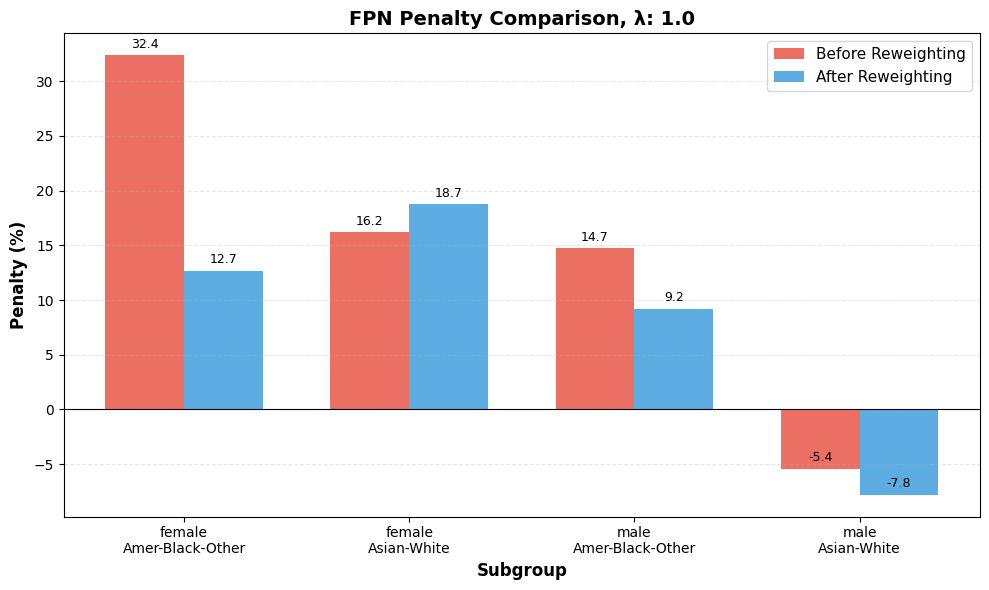


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → 12.69 (Δ = -19.66)
  female-Asian-White: 16.21 → 18.75 (Δ = +2.54)
  male-Amer-Black-Other: 14.75 → 9.22 (Δ = -5.53)
  male-Asian-White: -5.39 → -7.77 (Δ = -2.38)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.5108225108225108, '01': 1.4245054999260103, '10': 1.7198189134808852, '11': 0.906648995244505}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2033,  216],
       [ 330,  696]])}
{np.int64(1): array([[2954,  231],
       [ 372,  758]]), np.int64(0): array([[487,   7],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  75,   82]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1812,  207],
       [ 286,  687]]), '10': array([[226,   4],
       [ 33,  20]])}


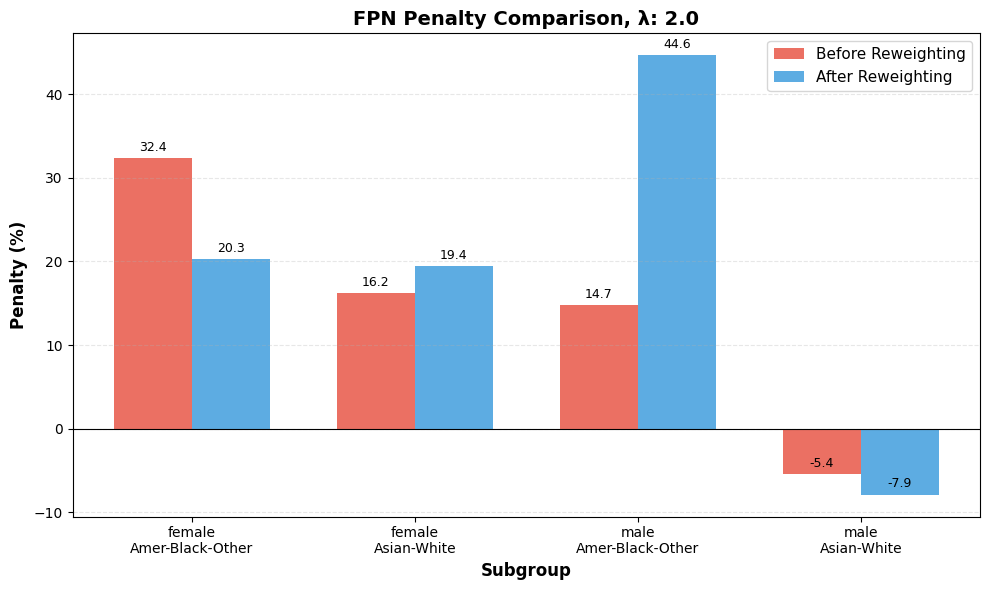


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → 20.25 (Δ = -12.10)
  female-Asian-White: 16.21 → 19.41 (Δ = +3.20)
  male-Amer-Black-Other: 14.75 → 44.64 (Δ = +29.89)
  male-Asian-White: -5.39 → -7.87 (Δ = -2.48)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 2.0612637498150255, '10': 2.7995472837022133, '11': 0.7666224881112627}
{np.int64(0): array([[1409,   21],
       [  92,   88]]), np.int64(1): array([[2047,  202],
       [ 332,  694]])}
{np.int64(1): array([[2969,  216],
       [ 379,  751]]), np.int64(0): array([[487,   7],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  79,   78]]), '00': array([[261,   3],
       [ 14,   9]]), '11': array([[1820,  199],
       [ 300,  673]]), '10': array([[225,   5],
       [ 31,  22]])}


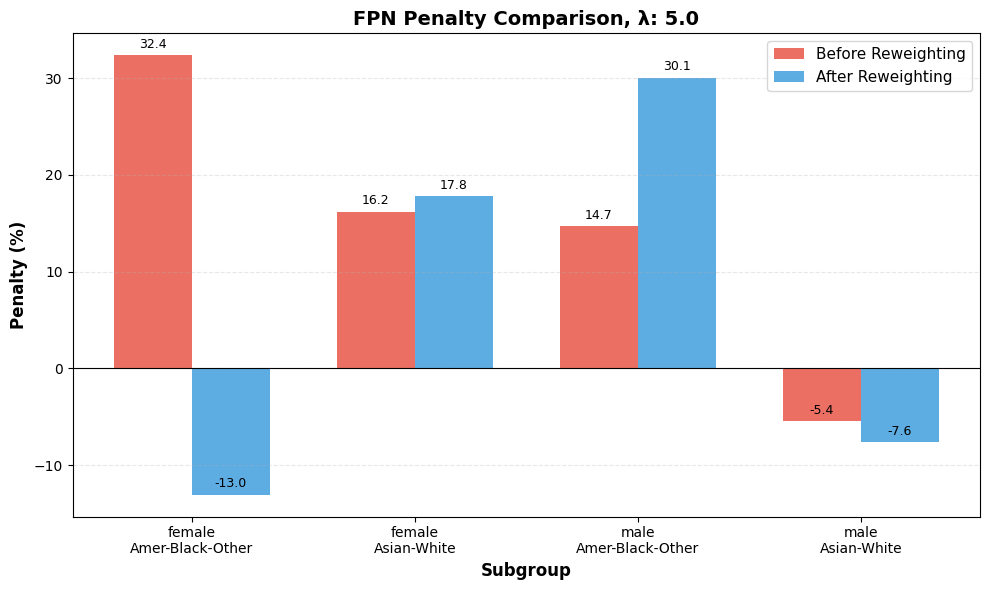


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → -13.03 (Δ = -45.38)
  female-Asian-White: 16.21 → 17.82 (Δ = +1.61)
  male-Amer-Black-Other: 14.75 → 30.05 (Δ = +15.31)
  male-Asian-White: -5.39 → -7.64 (Δ = -2.25)
------------------------------------------------------------
Training samples: 22792, Unique weights per group: {'00': 0.01, '01': 3.122527499630051, '10': 4.599094567404427, '11': 0.5332449762225253}
{np.int64(0): array([[1407,   23],
       [  90,   90]]), np.int64(1): array([[2049,  200],
       [ 343,  683]])}
{np.int64(1): array([[2971,  214],
       [ 387,  743]]), np.int64(0): array([[485,   9],
       [ 46,  30]])}
{'01': array([[1147,   19],
       [  76,   81]]), '00': array([[261,   3],
       [ 13,  10]]), '11': array([[1819,  200],
       [ 297,  676]]), '10': array([[224,   6],
       [ 32,  21]])}


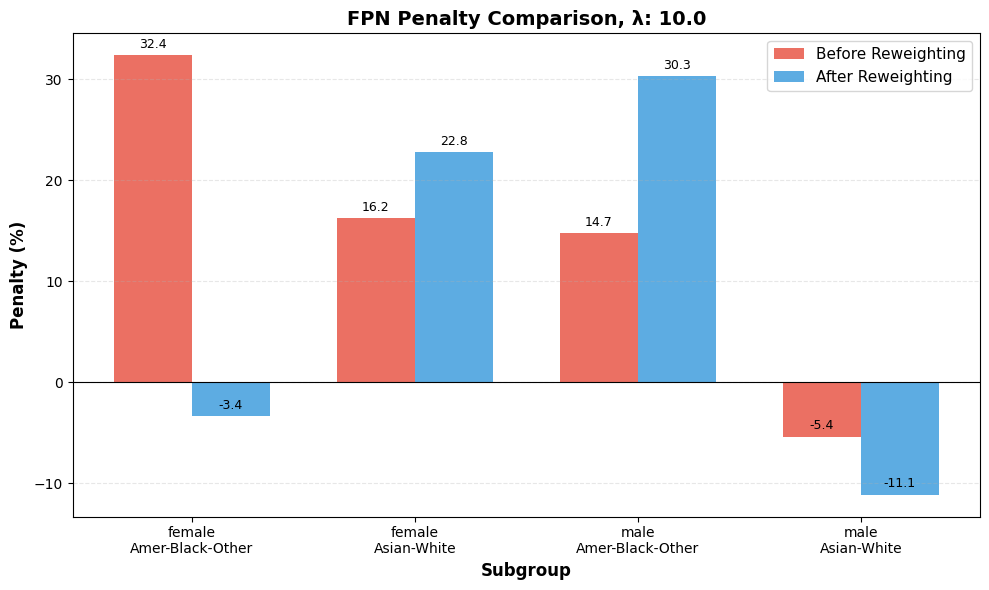


FPN - Penalty Changes:
  female-Amer-Black-Other: 32.35 → -3.35 (Δ = -35.70)
  female-Asian-White: 16.21 → 22.79 (Δ = +6.58)
  male-Amer-Black-Other: 14.75 → 30.32 (Δ = +15.57)
  male-Asian-White: -5.39 → -11.14 (Δ = -5.74)
------------------------------------------------------------


In [ ]:
for l in lambdas:
    penalties_ontest_after_reweighting = {}

    weights_notsized = compute_weights_notsized(l, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN']= compute_penalties_after_reweighting(weights_notsized, 'FPN', dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty

    plot_penalty_comparison_all_individual(['FPN'], penalties_ontest, penalties_ontest_after_reweighting, 
                                            sensible_attribute, mapping, l)

In [ ]:
if ALL_FM_L_NOTSIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_notsized = compute_weights_notsized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                    sensible_attribute, mapping, l)

In [ ]:
if SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

In [ ]:
if SIZED == 1 and ALL_FM_L_SIZED == 1:
    for l in lambdas:
        penalties_ontest_after_reweighting = {}

        for metric in fair_metrics:
            # print("FAIRNESS METRIC:", metric)
            weights_sized = compute_weights_sized(l, metric, penalties_onval, X_train, sensible_attribute)
            penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_sized, metric, dataset_path, sensible_attribute, X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels) # Get only harmonic penalty
            # print("\n")

        plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                                sensible_attribute, mapping, l)

Training samples: 22792, Unique weights per group: {'00': 0.8777056277056277, '01': 1.1061263749815025, '10': 1.1799547283702214, '11': 0.9766622488111263}
{np.int64(0): array([[1407,   23],
       [  89,   91]]), np.int64(1): array([[2048,  201],
       [ 337,  689]])}
{np.int64(1): array([[2967,  218],
       [ 379,  751]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1135,   31],
       [  70,   87]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1817,  202],
       [ 295,  678]]), '10': array([[225,   5],
       [ 33,  20]])}
Training samples: 22792, Unique weights per group: {'00': 0.7554112554112554, '01': 1.2122527499630051, '10': 1.3599094567404426, '11': 0.9533244976222526}
{np.int64(0): array([[1408,   22],
       [  91,   89]]), np.int64(1): array([[2049,  200],
       [ 333,  693]])}
{np.int64(1): array([[2969,  216],
       [ 377,  753]]), np.int64(0): array([[488,   6],
       [ 47,  29]])}
{'01': array([[1146,   20],
       [  77,  

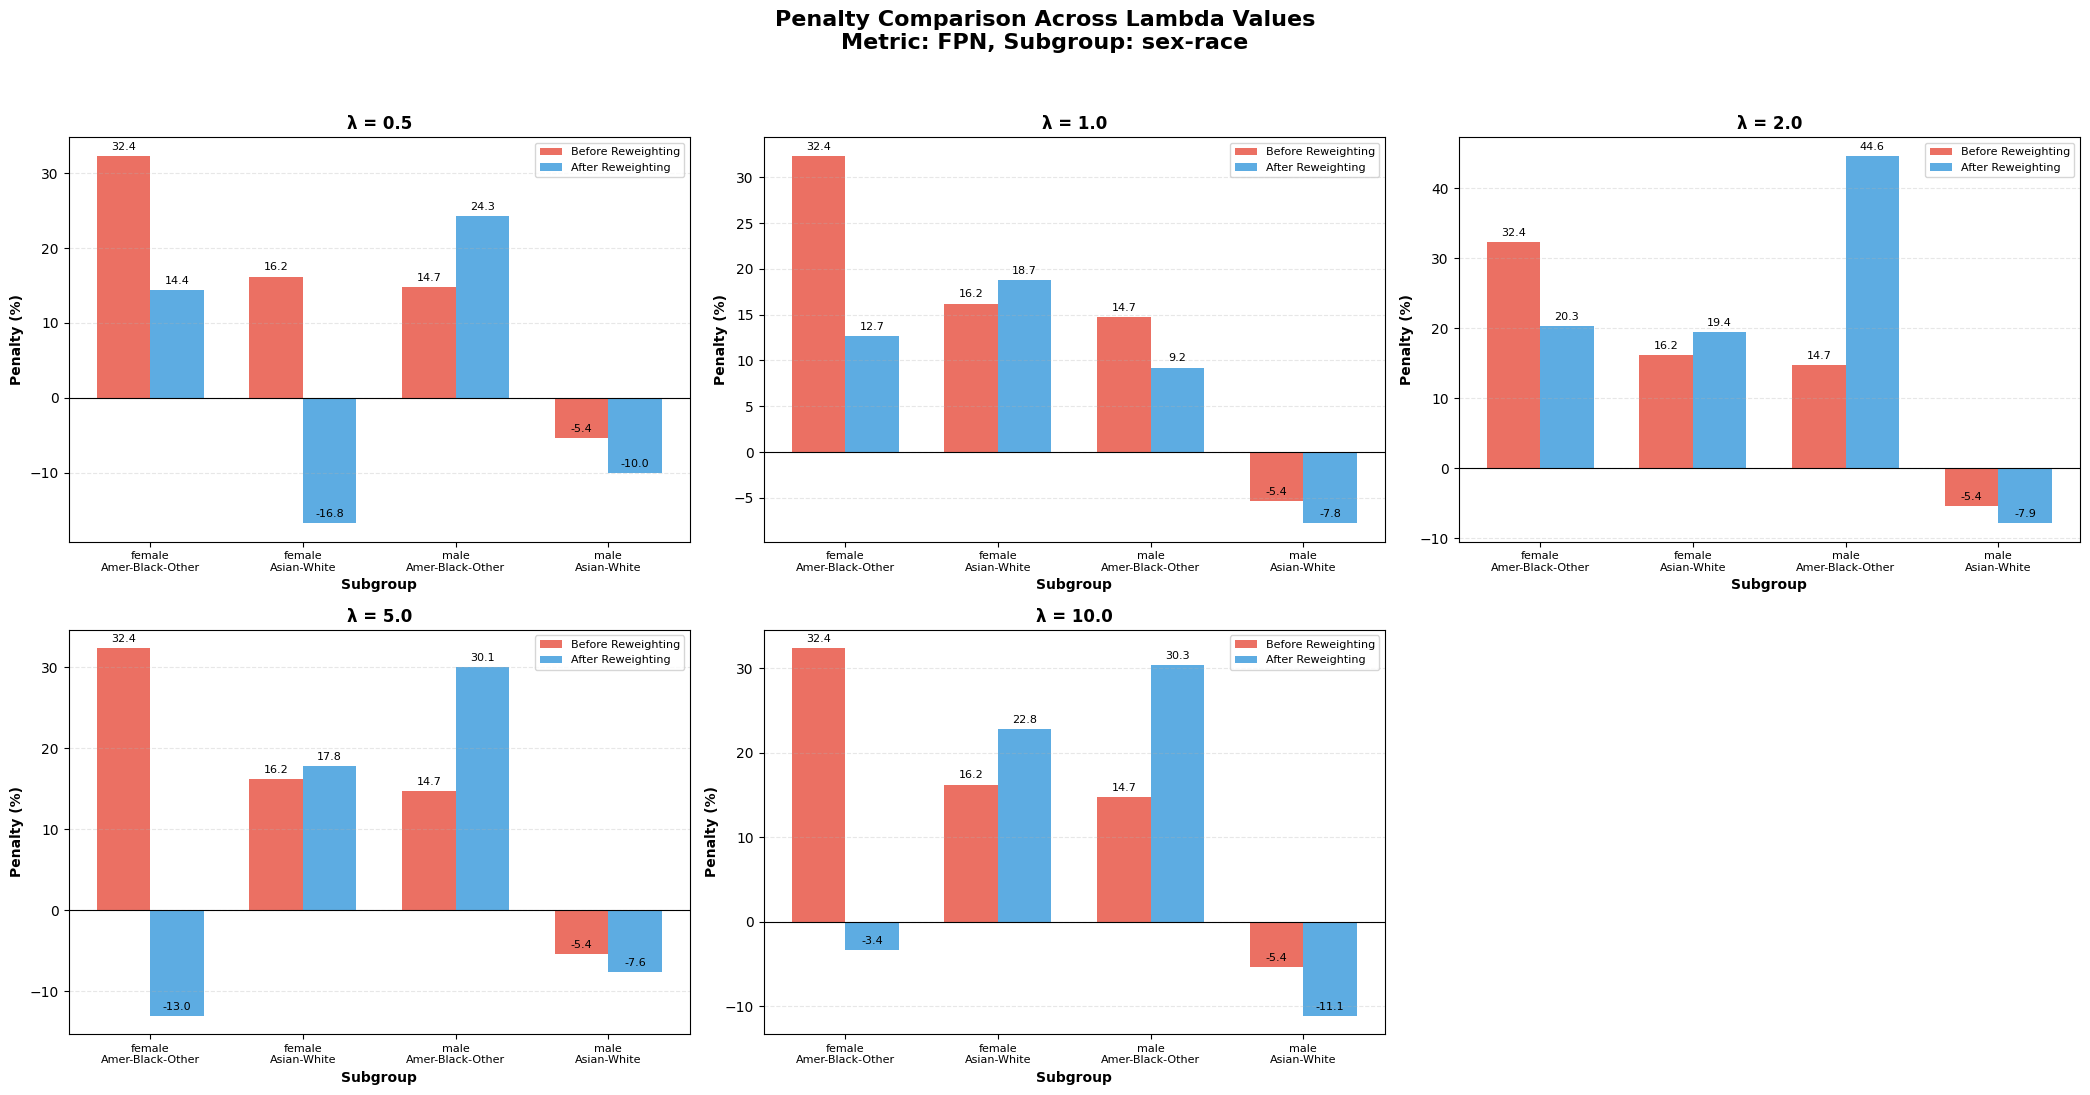

In [ ]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_notsized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)

Training samples: 22792, Unique weights per group: {'00': 0.9890322883219999, '01': 1.0476799655713998, '10': 1.0173266785387314, '11': 0.9766622488111263}
{np.int64(0): array([[1397,   33],
       [  83,   97]]), np.int64(1): array([[2048,  201],
       [ 329,  697]])}
{np.int64(1): array([[2958,  227],
       [ 367,  763]]), np.int64(0): array([[487,   7],
       [ 45,  31]])}
{'01': array([[1146,   20],
       [  79,   78]]), '00': array([[262,   2],
       [ 14,   9]]), '11': array([[1819,  200],
       [ 297,  676]]), '10': array([[224,   6],
       [ 32,  21]])}
Training samples: 22792, Unique weights per group: {'00': 0.9780645766439998, '01': 1.0953599311427993, '10': 1.0346533570774625, '11': 0.9533244976222526}
{np.int64(0): array([[1408,   22],
       [  89,   91]]), np.int64(1): array([[2049,  200],
       [ 336,  690]])}
{np.int64(1): array([[2969,  216],
       [ 379,  751]]), np.int64(0): array([[488,   6],
       [ 46,  30]])}
{'01': array([[1146,   20],
       [  77,  

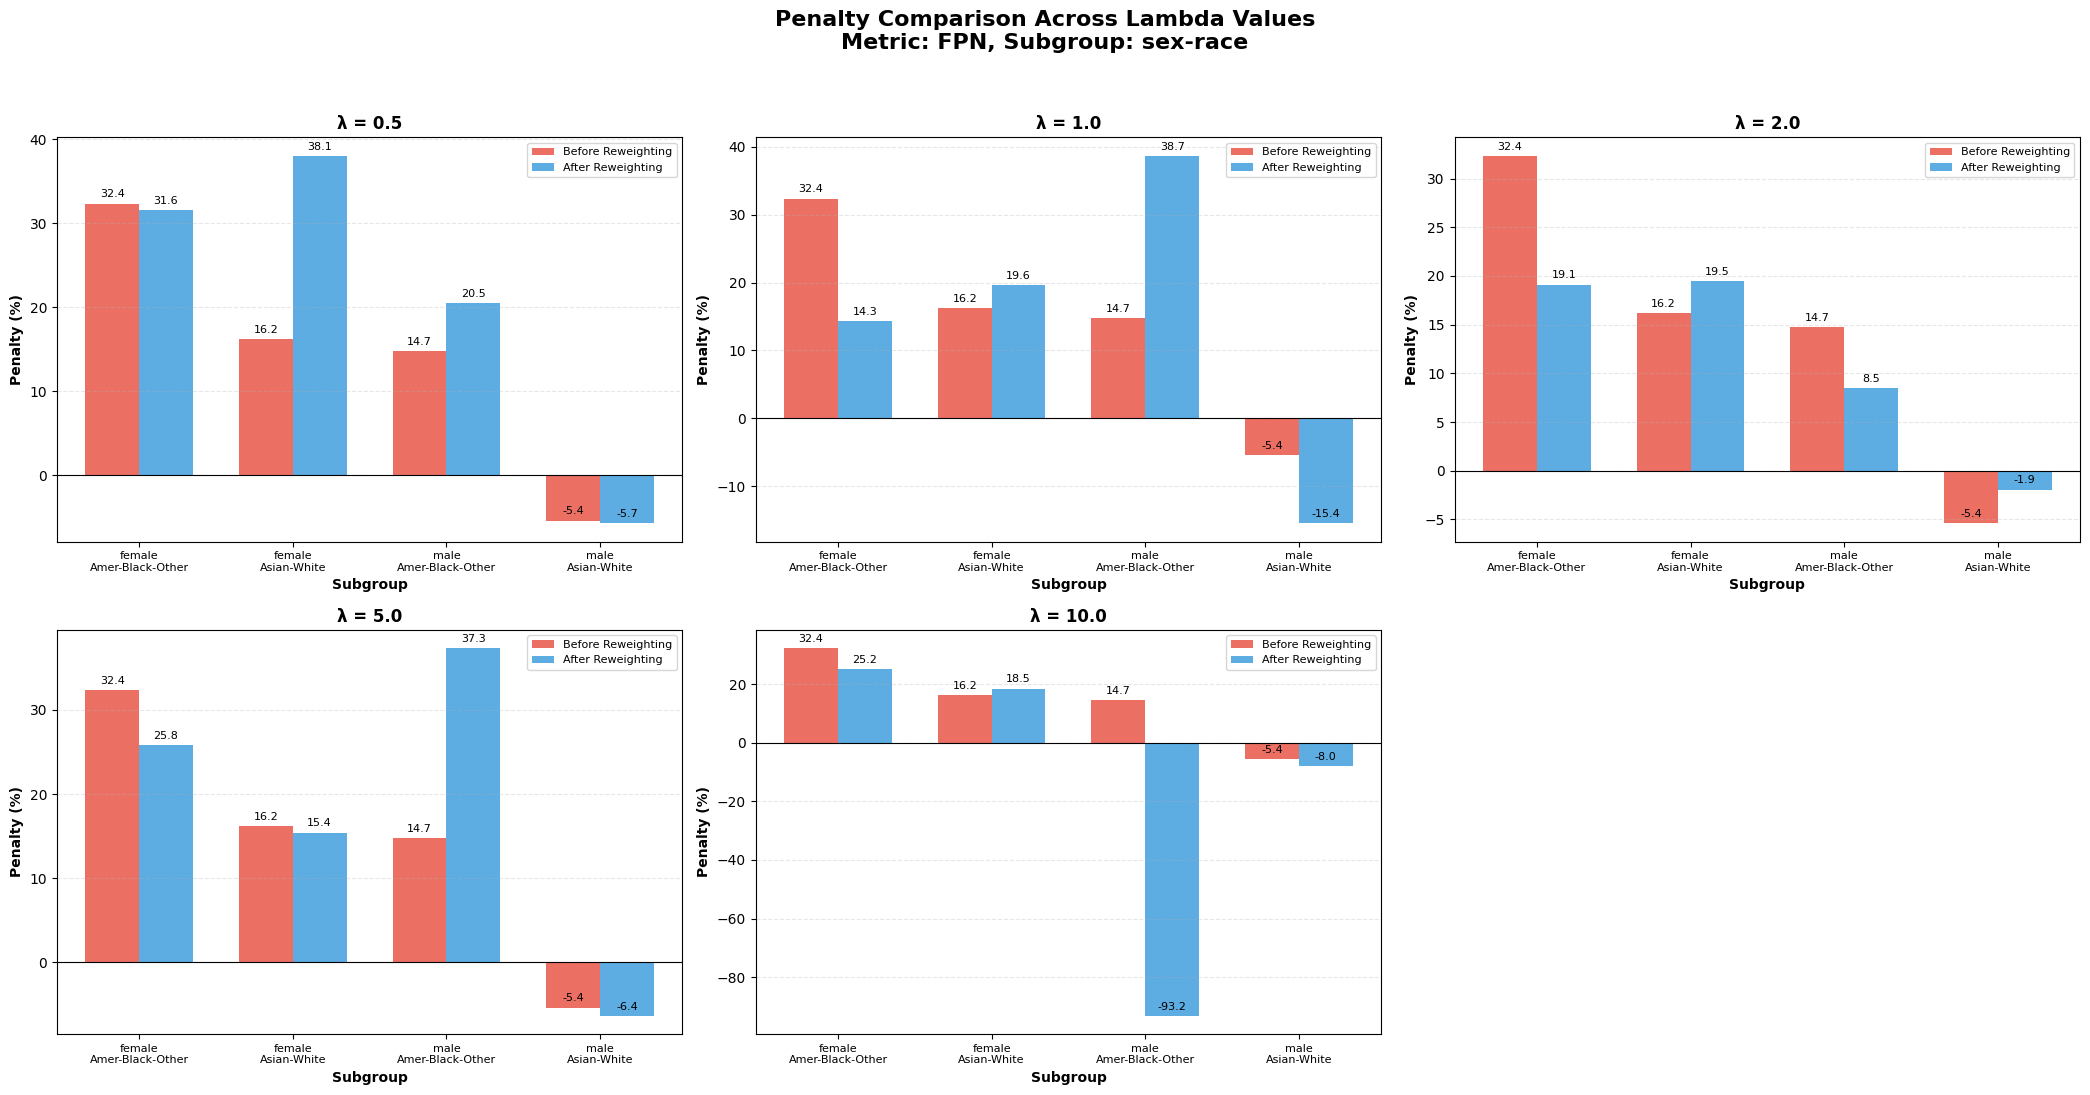

In [ ]:
# First, compute penalties for each lambda
penalties_after_by_lambda = {}
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

for lambd in lambdas:
    penalties_ontest_after_reweighting = {}
    weights_notsized = compute_weights_sized(lambd, 'FPN', penalties_onval, X_train, sensible_attribute)
    penalties_ontest_after_reweighting['FPN'] = compute_penalties_after_reweighting(
        weights_notsized, 'FPN', dataset_path, sensible_attribute, 
        X_train, y_train, X_test, y_test, fair_metrics, mapping, target_variable_labels
    )
    penalties_after_by_lambda[lambd] = penalties_ontest_after_reweighting

# Then plot
plot_penalty_comparison_lambdas('FPN', lambdas, penalties_ontest, penalties_after_by_lambda, 
                                sensible_attribute, mapping)